In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Load Titanic dataset
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

print("Titanic Dataset loaded successfully.")
print("Dataset shape:", titanic_df.shape)
print("\nFirst 5 rows:")
display(titanic_df.head())

Titanic Dataset loaded successfully.
Dataset shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Select useful features
titanic_features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

X_titanic = titanic_df[titanic_features].copy()
y_titanic = titanic_df['Survived']

# Encode categorical features
X_titanic['Sex'] = X_titanic['Sex'].map({
    'male': 0,
    'female': 1
})

X_titanic['Embarked'] = X_titanic['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

# Handle missing values
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_titanic)

# Standardize features
scaler_titanic = StandardScaler()
X_titanic_scaled = scaler_titanic.fit_transform(X_imputed)

# Stratified train-test split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic_scaled,
    y_titanic,
    test_size=0.20,
    stratify=y_titanic,
    random_state=42
)

print("Preprocessed Titanic dataset shapes:")
print(f"Training set features: {X_train_t.shape}")
print(f"Test set features: {X_test_t.shape}")

Preprocessed Titanic dataset shapes:
Training set features: (712, 7)
Test set features: (179, 7)


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Design ANN model
ann_titanic = Sequential([

    # Input layer + Hidden layer 1
    Dense(16, activation='relu', input_shape=(7,)),

    # Hidden layer 2
    Dense(8, activation='relu'),

    # Output layer
    Dense(1, activation='sigmoid')
])

print("Titanic ANN Architecture established:")
ann_titanic.summary()

Titanic ANN Architecture established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
ann_titanic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Titanic ANN model compiled successfully.")

Titanic ANN model compiled successfully.


In [5]:
history_titanic = ann_titanic.fit(
    X_train_t,
    y_train_t,
    epochs=50,
    batch_size=16,
    validation_split=0.20,
    verbose=1
)

print("\nTitanic ANN training complete.")

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4236 - loss: 0.7150 - val_accuracy: 0.6014 - val_loss: 0.6731
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6837 - loss: 0.6530 - val_accuracy: 0.7203 - val_loss: 0.6244
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7364 - loss: 0.5967 - val_accuracy: 0.7483 - val_loss: 0.5773
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7592 - loss: 0.5489 - val_accuracy: 0.7483 - val_loss: 0.5412
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7627 - loss: 0.5113 - val_accuracy: 0.7343 - val_loss: 0.5123
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7663 - loss: 0.4830 - val_accuracy: 0.7902 - val_loss: 0.4913
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7803 - loss: 0.4630 - val_accuracy: 0.7902 - val_loss: 0.4792
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7873 - loss: 0.4503 - val_accuracy: 0.7972 - val_loss:

In [6]:
from sklearn.metrics import accuracy_score

# Predict probabilities
y_pred_probs_t = ann_titanic.predict(X_test_t)

# Convert probabilities into classes
y_pred_classes_t = (y_pred_probs_t >= 0.5).astype(int)

# Calculate accuracy
test_accuracy_t = accuracy_score(
    y_test_t,
    y_pred_classes_t
)

print(f"Titanic ANN Test Accuracy: {test_accuracy_t * 100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Titanic ANN Test Accuracy: 80.45%


In [7]:
from sklearn.metrics import classification_report

print("--- Classification Report ---")

print(
    classification_report(
        y_test_t,
        y_pred_classes_t,
        target_names=['Not Survived', 'Survived']
    )
)

--- Classification Report ---
              precision    recall  f1-score   support

Not Survived       0.80      0.91      0.85       110
    Survived       0.81      0.64      0.72        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



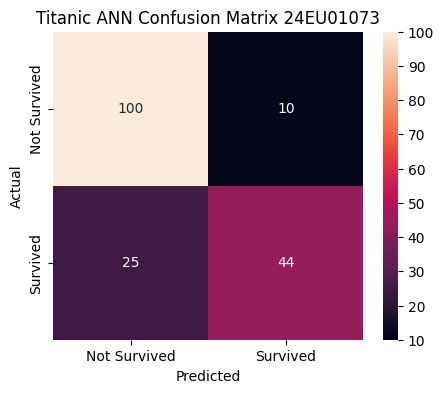

In [8]:
from sklearn.metrics import confusion_matrix

cm_titanic = confusion_matrix(
    y_test_t,
    y_pred_classes_t
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_titanic,
    annot=True,
    fmt='d',
    xticklabels=['Not Survived', 'Survived'],
    yticklabels=['Not Survived', 'Survived']
)

plt.title("Titanic ANN Confusion Matrix 24EU01073")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

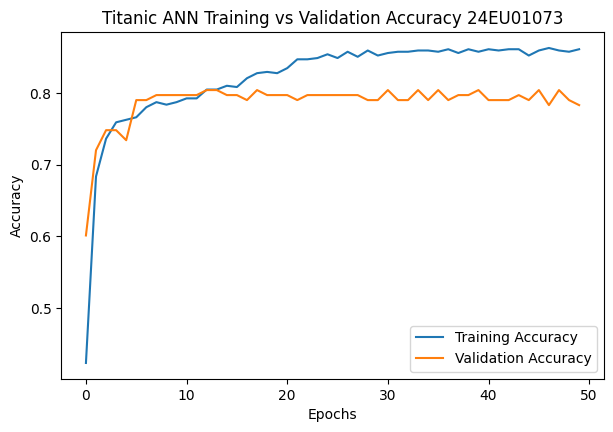

In [10]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    history_titanic.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_titanic.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Titanic ANN Training vs Validation Accuracy 24EU01073")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [11]:
print("========== TITANIC ANN EVALUATION ==========")

print(f"Test Accuracy : {test_accuracy_t * 100:.2f}%")

print("\nConfusion Matrix:")
print(cm_titanic)

print("\nClassification Report:")
print(
    classification_report(
        y_test_t,
        y_pred_classes_t,
        target_names=['Not Survived', 'Survived']
    )
)

========== TITANIC ANN EVALUATION ==========
Test Accuracy : 80.45%

Confusion Matrix:
[[100  10]
 [ 25  44]]

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.91      0.85       110
    Survived       0.81      0.64      0.72        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179

